In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split

Opgave 1

In [15]:
housing = pd.read_csv("housing.csv") # Indlæs datasæt

housing = housing.dropna() # Fjern manglende værdier

print(housing.head()) # De 5 første rækker

print(housing.info()) # Se de forskellige datatyper

print(housing.describe()) # Beskriver de forskellige datatyper

print(housing["ocean_proximity"].value_counts) # Hvor mange distrikter for hver 'ocean proximity'.

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (t

Hvilke begrænsninger er der ved typen "ocean_proximity"?
Der er kun 5 distrikter på hhv. en ISLAND, hvilket vil sige, at denne type ikke er særlig repræsentativ. Man kunne heraf overveje, om man skulle undlade at tage denne variabel med i en eventuel model el.lign.

Opgave 2: Undersøg distribution af data

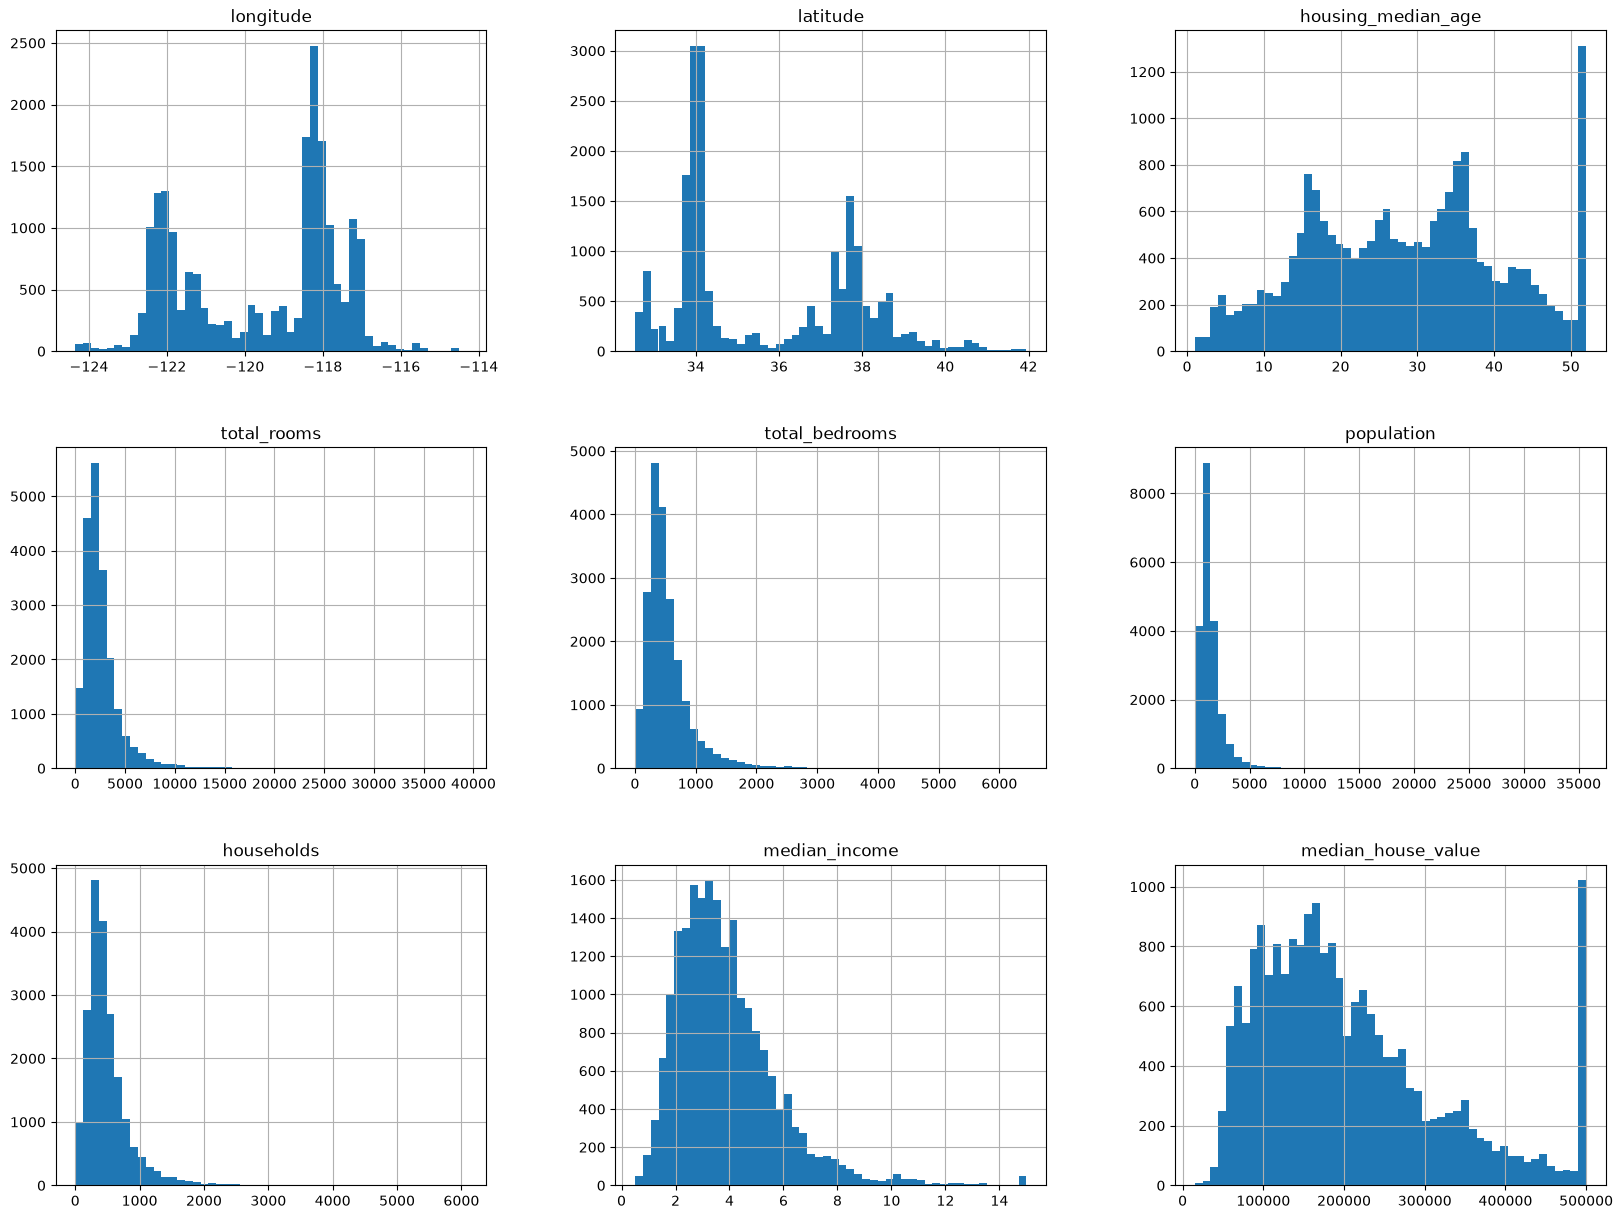

In [17]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

Outliers - Data som ligger ved siden af "ude af normen"

Clipping -  Hvis man vælger at udelukke bestemte data som ikke vil passe ind, som set på median_house_value til højre.

Dataet er cappet i mange af tilfældene. Fx med median_house_value, er markedsværdien på husene cappet ved 500.000 usd. Dette gør, at alle huse, der ligger over 500.000, bliver kategoriseret som 500.000. Derfor er denne graf en smule misvisende. (Man skal i hverfald være opmærksom på det)

Opgave 3: Stratified vs. Random Split

In [18]:
# Opret rooms_cat på hele DataFrame før split
housing["rooms_cat"] = pd.cut(housing["total_rooms"],
                               bins=[0., 5000, 10000, np.inf],
                               labels=[0, 1, 2])
test_size = 0.2

# Random split
train_set, test_set = train_test_split(housing, test_size=test_size, random_state=42)
# Stratified split (brug samme kolonne)
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=test_size, stratify=housing["rooms_cat"], random_state=42)

print("Random split (test):")
print(test_set["rooms_cat"].value_counts(normalize=True))

print("Stratified split (test):")
print(strat_test_set["rooms_cat"].value_counts(normalize=True))

# 4) Fjern rooms_cat igen fra de datasæt hvis I vil fortsætte videre uden den
for ds in (train_set, test_set, strat_train_set, strat_test_set):
    ds.drop(columns=["rooms_cat"], inplace=True)

Random split (test):
rooms_cat
0    0.908246
1    0.076829
2    0.014925
Name: proportion, dtype: float64
Stratified split (test):
rooms_cat
0    0.914852
1    0.071201
2    0.013947
Name: proportion, dtype: float64


Forskellen på random split og stratified split
    I random split, er det fuldstændige tilfældige data der bliver udvalgt i hhv. træningssæt og testsæt
    i stratified split, har de forskellige værdier den samme propotionalitet. Det vil sige, at hvis en "subgroup" fylder fx 50% i et datasæt, så ville den "subgroup" fylde hhv. 50% i både træningssættet og testsættet. 
    Dette vil ikke nødvendigvis være tilfældet i et random split.

Opgave 4: Korrelationer mellem features

median_house_value    1.000000
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
longitude            -0.045398
latitude             -0.144638
Name: median_house_value, dtype: float64


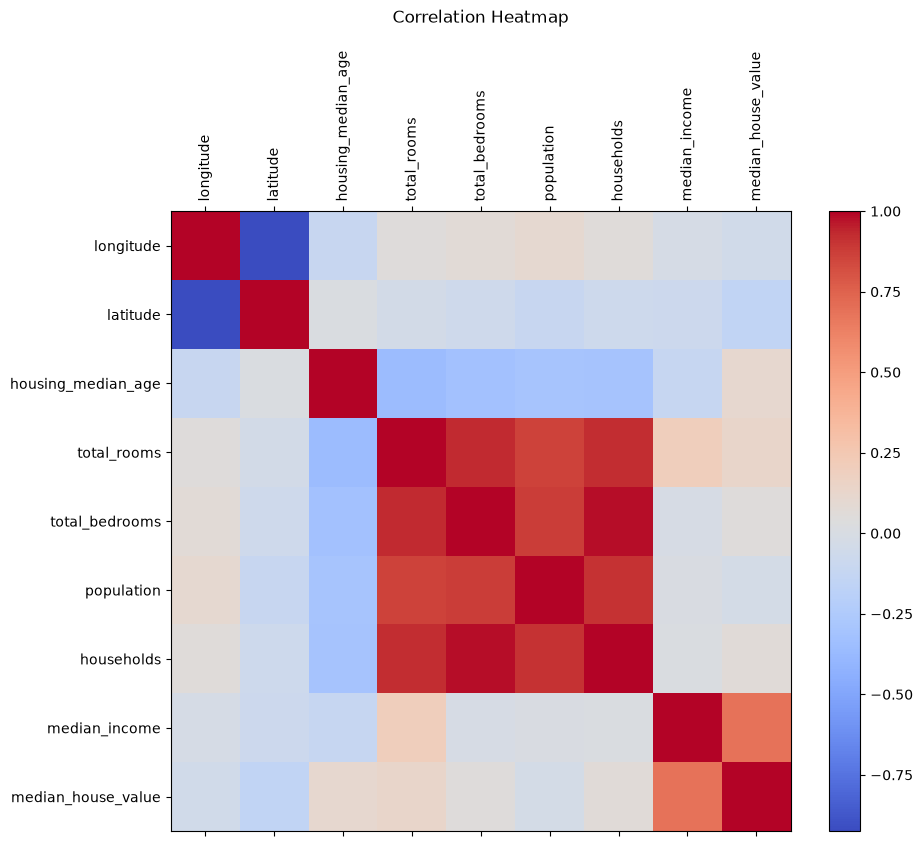

In [20]:
corr_matrix = housing.select_dtypes(include=[np.number]).corr()
print(corr_matrix["median_house_value"].sort_values(ascending=False))

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.matshow(corr_matrix, cmap="coolwarm", fignum=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap", pad=20)
plt.show()

Hvilke features har stærkest sammenhæng med huspriserne?
    median_house_value og median_income. Dette giver mening, for det ville jo typisk være folk med felst penge, der køber de dyreste huse.

Er der features, der nærmest ikke har nogen sammenhæng?
    Stort set alle de andre features har tæt på ingen sammenhæng.

Opgave 5: Scatterplots og sammenhænge

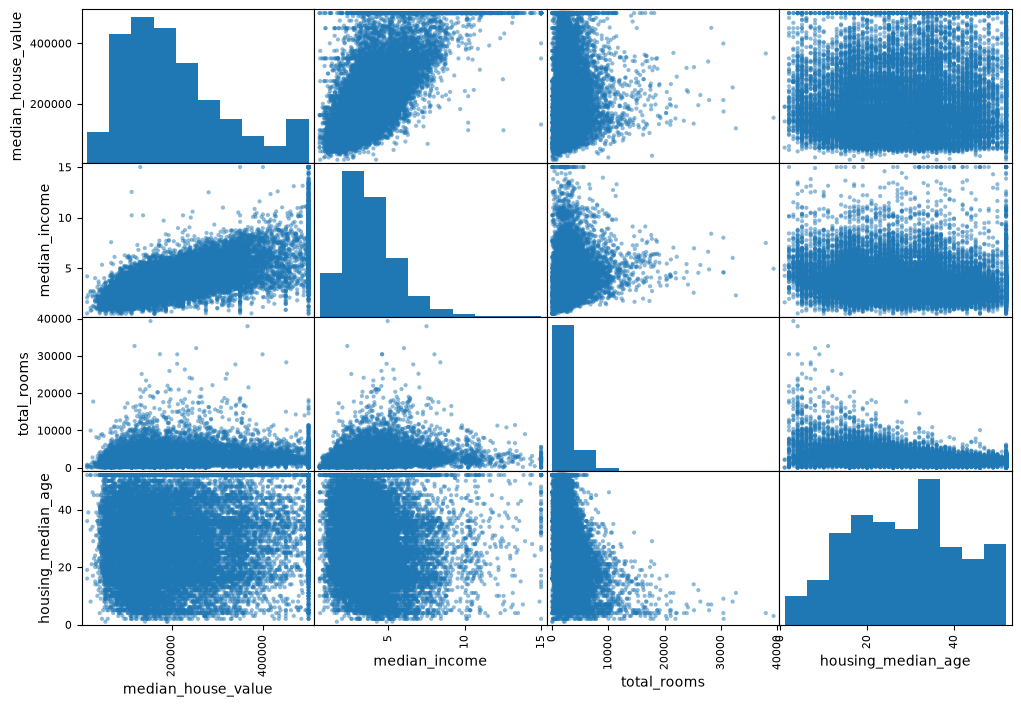

In [21]:
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

Hvilken feature ser ud til at være den bedste indikator for boligpriser?
    Ud fra scatterplotsne, ser det ud som om, at median_income virker som den bedste indikator for boligpriser, da det er der, der er størst sammenhæng.
    Som beskrevet før, giver det mening, da det jo typisk er folk der har flest penge, der køber de dyreste huse.